In [1]:
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import v2

In [2]:
training_data = datasets.FashionMNIST(
    root="/tmp/data",
    train=True,
    download=True,
    transform=v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)]),
)
test_data = datasets.FashionMNIST(
    root="/tmp/data",
    train=False,
    download=True,
    transform=v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)]),
)

In [3]:
batch_size = 64

# Create data loaders.
train_dataloader = DataLoader(training_data, batch_size=batch_size)
test_dataloader = DataLoader(test_data, batch_size=batch_size)

for X, y in test_dataloader:
    print(f"Shape of X [N, C, H, W]: {X.shape}")
    print(f"Shape of y: {y.shape} {y.dtype}")
    break

Shape of X [N, C, H, W]: torch.Size([64, 1, 28, 28])
Shape of y: torch.Size([64]) torch.int64


Pour définir un réseau neuronal dans PyTorch, on crée une classe qui hérite de nn.Module

Module = Classe de base pour tous les modules de réseau de neurones, on la définit nous même

la fonction __init__ = les couches du réseau de neurones sont définies dedans

fonction foward = comment les données vont passer dans le RN

Contrôle total sur archi et entrainement

In [4]:
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using {device} device")

# Define model
class NeuralNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.linear_relu_stack = nn.Sequential(
            nn.Linear(28*28, 512),
            nn.ReLU(),
            nn.Linear(512, 512),
            nn.ReLU(),
            nn.Linear(512, 10)
        )

    def forward(self, x):
        x = self.flatten(x)
        logits = self.linear_relu_stack(x)
        return logits

model = NeuralNetwork().to(device)
print(model)

Using cpu device
NeuralNetwork(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear_relu_stack): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=512, bias=True)
    (3): ReLU()
    (4): Linear(in_features=512, out_features=10, bias=True)
  )
)


/home/ima9630/pytorch/.venv/lib/python3.10/site-packages/torch/cuda/__init__.py:187: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 12020). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._cuda_getDeviceCount() > 0


fonction de perte :
- utilisée pour les problèmes de classification multiclasse(=)
- compare prédictions du modèle aux vraies étiquettes
- plus la valeur est faible, meilleures sont les prédictions

optimiseur :

- crée un optimiseur de type SGD (Stochastic Gradient Descent)
= > récupère tous les poids et biais du réseau --> paramètres qui se modifient pendant l'apprentissage



In [5]:
loss_fn = nn.CrossEntropyLoss() #pas trop compris comment ça fonctionne concrètement
optimizer = torch.optim.SGD(model.parameters(), lr=1e-3)

In [6]:
def train(dataloader, model, loss_fn, optimizer):
    size = len(dataloader.dataset)
    model.train()
    for batch, (X, y) in enumerate(dataloader):
        X, y = X.to(device), y.to(device)

        pred = model(X)
        loss = loss_fn(pred, y)

        loss.backward() #calcul les gradients(= dire la direction dans laquelle aller, dit de combien il faut ajuster les poids)
        optimizer.step() #utlise les gradients pour réajuster les poids
        optimizer.zero_grad() #efface les anciens gradients car pytorch les aditionne automatiquement

        if batch % 100 == 0: #tous les 100 batch on affiche l'information
            loss, current = loss.item(), (batch + 1) * len(X) #converti un tensor en un nombre python (=stock un nombre, differente forme selon son nombre de dimensions, current = ce qui est déjà traité
            print(f"loss: {loss:>7f}  [{current:>5d}/{size:>5d}]")

tensor =

exemple 0D : un nombre

x = torch.tensor(5) Contient : 5

exemple 1D : un vecteur
x = torch.tensor([1, 2, 3]) Contient : [1, 2, 3]

exemple 2D : une matrice
x = torch.tensor([
    [1, 2],
    [3, 4]
])

Contient :

1 2
3 4

In [7]:
def test(dataloader, model, loss_fn):
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    model.eval()
    test_loss, correct = 0, 0
    with torch.no_grad(): # dis à torch de ne pas calculer les gradients -> avantages : moins de mémoire, plus rapide, pas de rétropropagation
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            pred = model(X)
            test_loss += loss_fn(pred, y).item()
            correct += (pred.argmax(1) == y).type(torch.float).sum().item() #argmax = indice de score maximal
    test_loss /= num_batches
    correct /= size #transform nombre de bonnes réponses en proportions
    print(f"Test Error: \n Accuracy: {(100*correct):>0.1f}%, Avg loss: {test_loss:>8f} \n")

In [8]:
epochs = 5
for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")
    train(train_dataloader, model, loss_fn, optimizer)
    test(test_dataloader, model, loss_fn)
print("Done!")

Epoch 1
-------------------------------
loss: 2.315885  [   64/60000]
loss: 2.298762  [ 6464/60000]
loss: 2.272974  [12864/60000]
loss: 2.266311  [19264/60000]
loss: 2.243387  [25664/60000]
loss: 2.216524  [32064/60000]
loss: 2.226279  [38464/60000]
loss: 2.187599  [44864/60000]
loss: 2.201260  [51264/60000]
loss: 2.154732  [57664/60000]
Test Error: 
 Accuracy: 42.5%, Avg loss: 2.153075 

Epoch 2
-------------------------------
loss: 2.171634  [   64/60000]
loss: 2.153640  [ 6464/60000]
loss: 2.088186  [12864/60000]
loss: 2.107394  [19264/60000]
loss: 2.051839  [25664/60000]
loss: 1.997780  [32064/60000]
loss: 2.025597  [38464/60000]
loss: 1.937170  [44864/60000]
loss: 1.963458  [51264/60000]
loss: 1.880262  [57664/60000]
Test Error: 
 Accuracy: 53.6%, Avg loss: 1.874574 

Epoch 3
-------------------------------
loss: 1.919682  [   64/60000]
loss: 1.876803  [ 6464/60000]
loss: 1.752288  [12864/60000]
loss: 1.795660  [19264/60000]
loss: 1.688224  [25664/60000]
loss: 1.645945  [32064/600

In [9]:
torch.save(model.state_dict(), "model.pth")
print("Saved PyTorch Model State to model.pth")

Saved PyTorch Model State to model.pth


In [13]:
classes = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot",
]

model.eval()
x, y = test_data[0][0], test_data[0][1]
with torch.no_grad():
    x = x.to(device)
    pred = model(x)
    predicted, actual = classes[pred[0].argmax(0)], classes[y]
    print(f'Predicted: "{predicted}", Actual: "{actual}"')

Predicted: "Ankle boot", Actual: "Ankle boot"


# visualisation des données

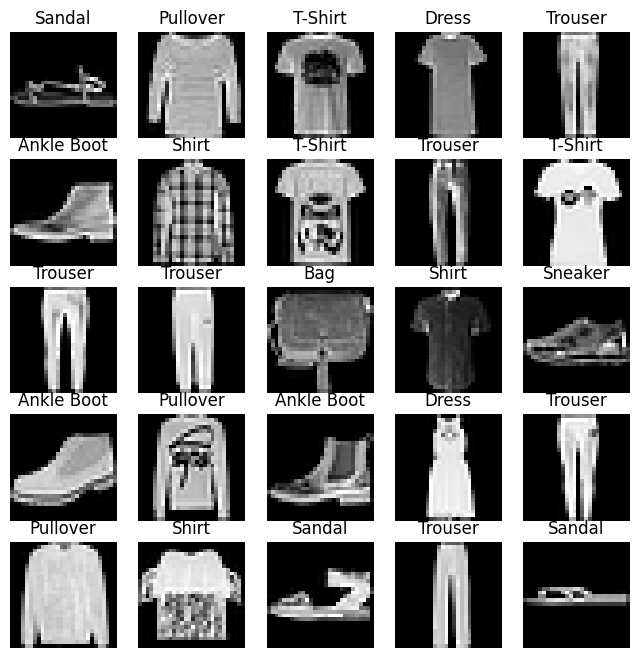

In [17]:
import matplotlib.pyplot as plt

labels_map = {
    0: "T-Shirt",
    1: "Trouser",
    2: "Pullover",
    3: "Dress",
    4: "Coat",
    5: "Sandal",
    6: "Shirt",
    7: "Sneaker",
    8: "Bag",
    9: "Ankle Boot",
}
figure = plt.figure(figsize=(8, 8))
cols, rows = 5, 5
for i in range(1, cols * rows + 1):
    sample_idx = torch.randint(len(training_data), size=(1,)).item()
    img, label = training_data[sample_idx]
    figure.add_subplot(rows, cols, i)
    plt.title(labels_map[label])
    plt.axis("off")
    plt.imshow(img.squeeze(), cmap="gray")
plt.show()